# Las losowy

## Zadanie na 3

Implementacja lasu losowego

#### Import bibliotek

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from scipy.io import arff
from sklearn.model_selection import GridSearchCV

#### Funkcje do oceny skuteczności 

In [9]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

### Wygenerowanie danych

Jednomodowe - make_classification

In [10]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])
X_classification, y_classification = make_classification(
    n_samples=my_n_samples, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    random_state=my_index,
)

print('x', X_classification.shape)
print('y', y_classification.shape)

x (2599, 2)
y (2599,)


Jednomodowe - make_moons

In [11]:
X_moons, y_moons = make_moons(n_samples=my_n_samples, noise=0.2, random_state=my_index)

print('X_moons', X_moons.shape)
print('y_moons', y_moons.shape)

X_moons (2599, 2)
y_moons (2599,)


Wielomodowy - make_blobs

In [12]:
X_blobs, y_blobs = make_blobs(
    n_samples=my_n_samples,
    centers=2,
    n_features=2,
    random_state=my_index
)

print('X_blobs', X_blobs.shape)
print('y_blobs', y_blobs.shape)

X_blobs (2599, 2)
y_blobs (2599,)


#### Podział danych na treningowe i testowe

In [13]:
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=my_index
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=my_index
)

X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs, y_blobs, test_size=0.2, random_state=my_index
)

print("classification:", X_classification_train.shape, y_classification_train.shape, X_classification_test.shape, y_classification_test.shape)
print("nmoons:", X_moons_train.shape, y_moons_train.shape, X_moons_test.shape, y_moons_test.shape)
print("blobs:", X_blobs_train.shape, y_blobs_train.shape, X_blobs_test.shape, y_blobs_test.shape)


classification: (2079, 2) (2079,) (520, 2) (520,)
nmoons: (2079, 2) (2079,) (520, 2) (520,)
blobs: (2079, 2) (2079,) (520, 2) (520,)


### Własna implementacja

#### Porównanie wyników 

Własna implementacja

In [14]:
results = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])


RandomForestClassifier

classification
Accuracy: 0.93, Sensitivity: 0.91, Specificity: 0.95


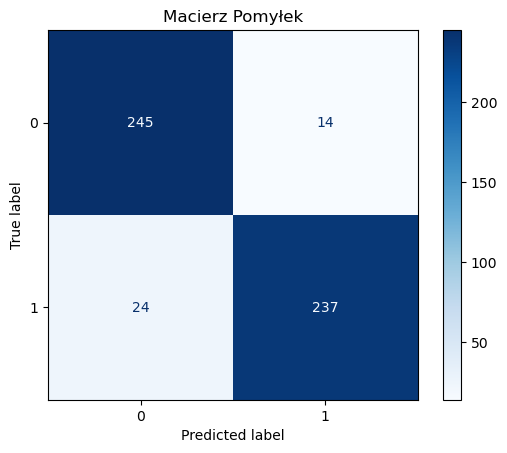

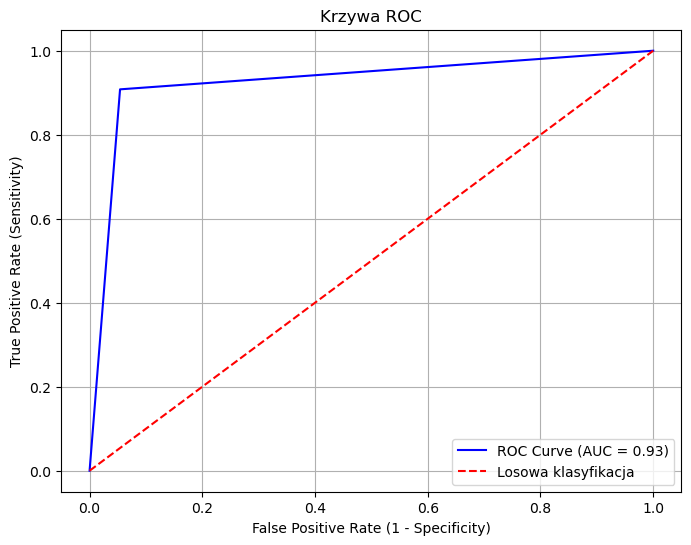

moons
Accuracy: 0.98, Sensitivity: 0.98, Specificity: 0.98


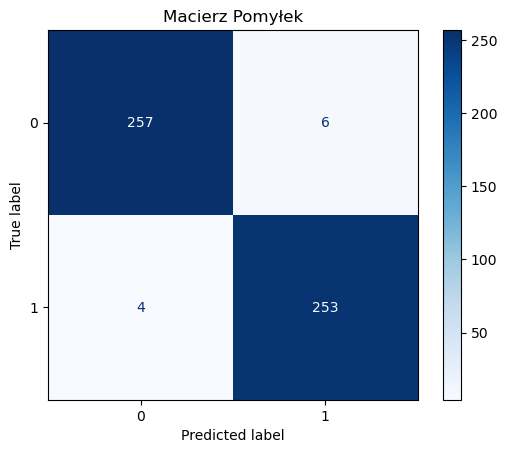

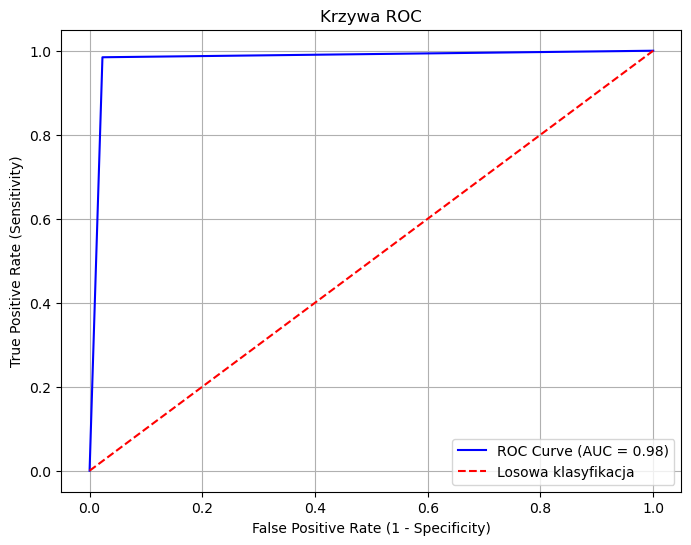

blobs
Accuracy: 1.00, Sensitivity: 1.00, Specificity: 1.00


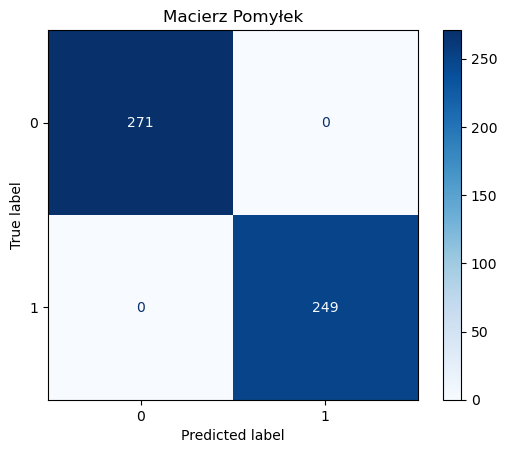

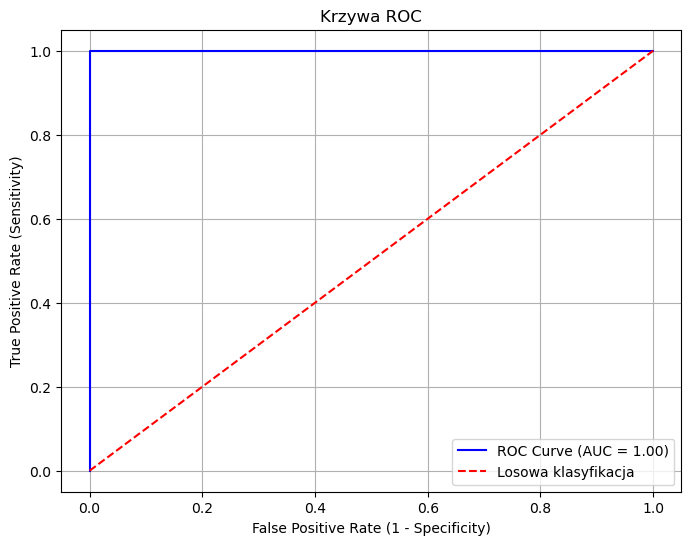

In [15]:
clf_classification = RandomForestClassifier(random_state=my_index)
clf_classification.fit(X_classification_train, y_classification_train)
y_pred_classification = clf_classification.predict(X_classification_test)

print("classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_classification)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - classification"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_classification_test, y_pred_classification)
plot_roc_curve(y_classification_test, y_pred_classification)

clf_moons = RandomForestClassifier(random_state=my_index)
clf_moons.fit(X_moons_train, y_moons_train)
y_pred_moons = clf_moons.predict(X_moons_test)

print("moons")
accuracy, sensitivity, specificity = calculate_metrics(y_moons_test, y_pred_moons)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - moons"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_moons_test, y_pred_moons)
plot_roc_curve(y_moons_test, y_pred_moons)

clf_blobs = RandomForestClassifier(random_state=my_index)
clf_blobs.fit(X_blobs_train, y_blobs_train)
y_pred_blobs = clf_blobs.predict(X_blobs_test)

print("blobs")
accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred_blobs)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - blobs"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_blobs_test, y_pred_blobs)
plot_roc_curve(y_blobs_test, y_pred_blobs)

In [16]:
pd.DataFrame(results)

,Accuracy,Sensitivity,Specificity
sklearn RF - classification,0.926923,0.908046,0.945946
sklearn RF - moons,0.980769,0.984436,0.977186
sklearn RF - blobs,1.000000,1.000000,1.000000


## Zadanie na 4

Analiza zbioru NASA JPL Asteroid w oparciu o las losowy

#### Wczytanie danych 

In [19]:
file_path = f'./Datasets/NASA_JPL_asteroid.csv'
data = pd.read_csv(file_path, low_memory=False)

data.head()
print(data.shape)

(958524, 45)
